In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import os
import torch
import numpy as np
from preprocess_functions import crop_and_resize_square,normalize_image

In [282]:

def patient_preprocess(patient):
    patient[:,:122]=0
    patient[:,508:]=0
    patient[:100]=0
    patient[680:]=0

    patient = crop_and_resize_square(patient)
    patient = normalize_image(patient)
    patient = torch.tensor(patient,dtype=torch.float32)
    patient = patient.unsqueeze(0)
    return patient


def label_preprocess(img):
    values = np.unique(img)
    template = []
    for i,v in enumerate(values):
        gray =( img ==v).copy().astype(np.uint8)
        gray = gray*255

        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((7,7), np.uint8))

        filled = binary_fill_holes(thresh > 0).astype(np.uint8) * 255
    

        filled =crop_and_resize_square(filled)
        template.append(filled)
    
    template = np.stack(template,axis=2)

    template[:,:,0] = template[:, :, 1:].sum(axis=2)

    template =torch.tensor(template,dtype=torch.uint8)
    template = template.permute(2,0,1)
    template=  (template>0).int()
    return template



In [283]:
root ='../../../data/CardiacUDA/original_data/test/Site_test'
target_folder = '../../../data/CardiacUDA/test'
os.makedirs(target_folder,exist_ok=True)
for file in os.listdir(root):
    if "image" in file:
        patient_file = os.path.join(root,file)
        label_file = os.path.join(root,file.replace('image','label'))

        patient_data = nib.load(patient_file).get_fdata()
        label_data = nib.load(label_file).get_fdata()

        assert patient_data.shape == label_data.shape

        
        patient_folder = os.path.join(target_folder,file.split('_')[0])

        os.makedirs(patient_folder,exist_ok=True)

        slices = patient_data.shape[2]

        for i in range(slices):

            slice_path = os.path.join(patient_folder,f'slice_{i}')

            os.makedirs(slice_path,exist_ok=True)
            data_path = os.path.join(slice_path,f'slice.pt')
            label_path = os.path.join(slice_path,f'label.pt')
            data = patient_data[:,:,i] 
            data =patient_preprocess(data)
            label = label_data[:,:,i]
            label = label_preprocess(label)

            torch.save(data,data_path)
            torch.save(label,label_path)
            
            





In [266]:
from torch.utils.data import Dataset
import os

class UDATestDataset(Dataset):
    def __init__(self,
                root ='../../../data/CardiacUDA/test' ):
        super().__init__()  

        self.get_folder_path = lambda x : [os.path.join(x,f) for f in os.listdir(x)]
        self.root = root
        self.data_paths= []

        self.patient_paths= self.get_folder_path(self.root)
        for p in self.patient_paths:
            slice_paths = self.get_folder_path(p)
            for s in slice_paths:
                data_path  =os.path.join(s,'slice.pt')
                label_path = os.path.join(s,'label.pt')
                self.data_paths.append((data_path,label_path))

        self.len =len(self.data_paths)

    def __getitem__(self,idx):
        data_path,label_path =self.data_paths[idx]
        data = torch.load(data_path)
        label = torch.load(label_path)
        return data,label
dataset =UDATestDataset()
dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0,

In [281]:
torch.unique(dataset[0][1][1])

tensor([  0,   1,   2,   3,  14,  16,  23,  28,  32,  36,  44,  48,  49,  52,
         63,  65,  85,  87,  88, 114, 115, 116, 121, 123, 124, 130, 133, 139,
        146, 150, 155, 162, 176, 183, 185, 187, 188, 195, 202, 203, 204, 211,
        214, 219, 227, 231, 242, 249, 252, 253, 254, 255], dtype=torch.uint8)

In [278]:
x =dataset[0][1][1]>0
x = x.int()

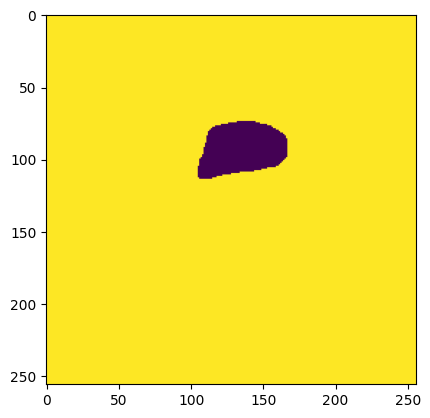

In [280]:
plt.imshow(1-x)